In [ ]:
!pip install pennylane


Se construye un circuito cuántico organizado como una **red tensorial tipo MPS (Matrix Product State)**

Se define bloque que se repite en la red tensorial: RX → rotación en X en un qubit
RY → rotación en Y en otro qubit
CNOT → entrelazamiento entre ambos

In [2]:
import numpy as onp
import pennylane as qml
from pennylane import numpy as np


def block(weights, wires):
    qml.RX(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=wires)

se toma el bloque y se repite en forma de cadena (MPS) sobre los qubits

shape [3, 2]:

3 → número de bloques en el circuito (3 “capas” MPS)

2 → número de parámetros por bloque, 1 parámetro para RX, 1 parámetro para RY

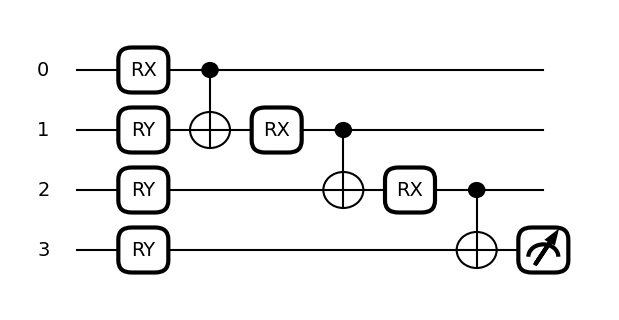

In [3]:
dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def circuit(template_weights):
    qml.MPS(
        wires=range(4),
        n_block_wires=2,
        block=block,
        n_params_block=2,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=3)) #miden el qubit 3 en base Z (+-1)


np.random.seed(1)
weights = np.random.random(size=[3, 2])
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(circuit, level="device")(weights)
fig.set_size_inches((6, 3))

Using the **MPS template** we can easily change the block type, depth, and size. For example, the block can contain a template like **StronglyEntanglingLayers**, yielding a deeper block. El bloque tiene más puertas.

In [5]:
def deep_block(weights, wires):
    qml.StronglyEntanglingLayers(weights, wires)

In [6]:
dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def circuit(template_weights):
    qml.MPS(
        wires=range(4),
        n_block_wires=2, #bond dimension
        block=deep_block,
        n_params_block=3,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=3))


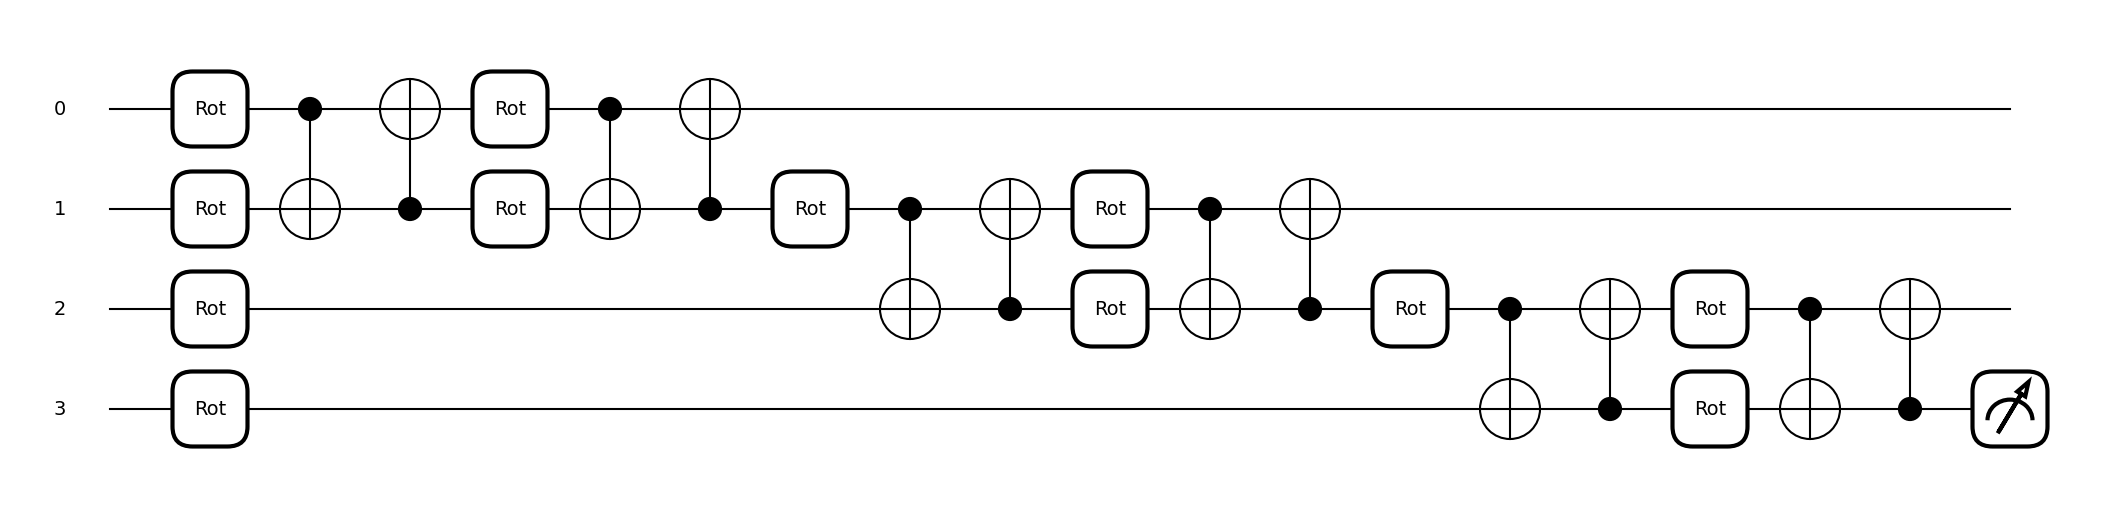

In [8]:
shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=2)#cuántos parámetros necesita un bloque de este tipo
template_weights = [np.random.random(size=shape)] *3 #crea 3 bloques idénticos de pesos, mi circuito tiene 3 bloques MPS, y todos usan la misma estructura de parámetros
fig, ax = qml.draw_mpl(circuit, level="device")(template_weights)


Bloques más amplio, es decir, mayor bond dimension, mayor entrelazamiento

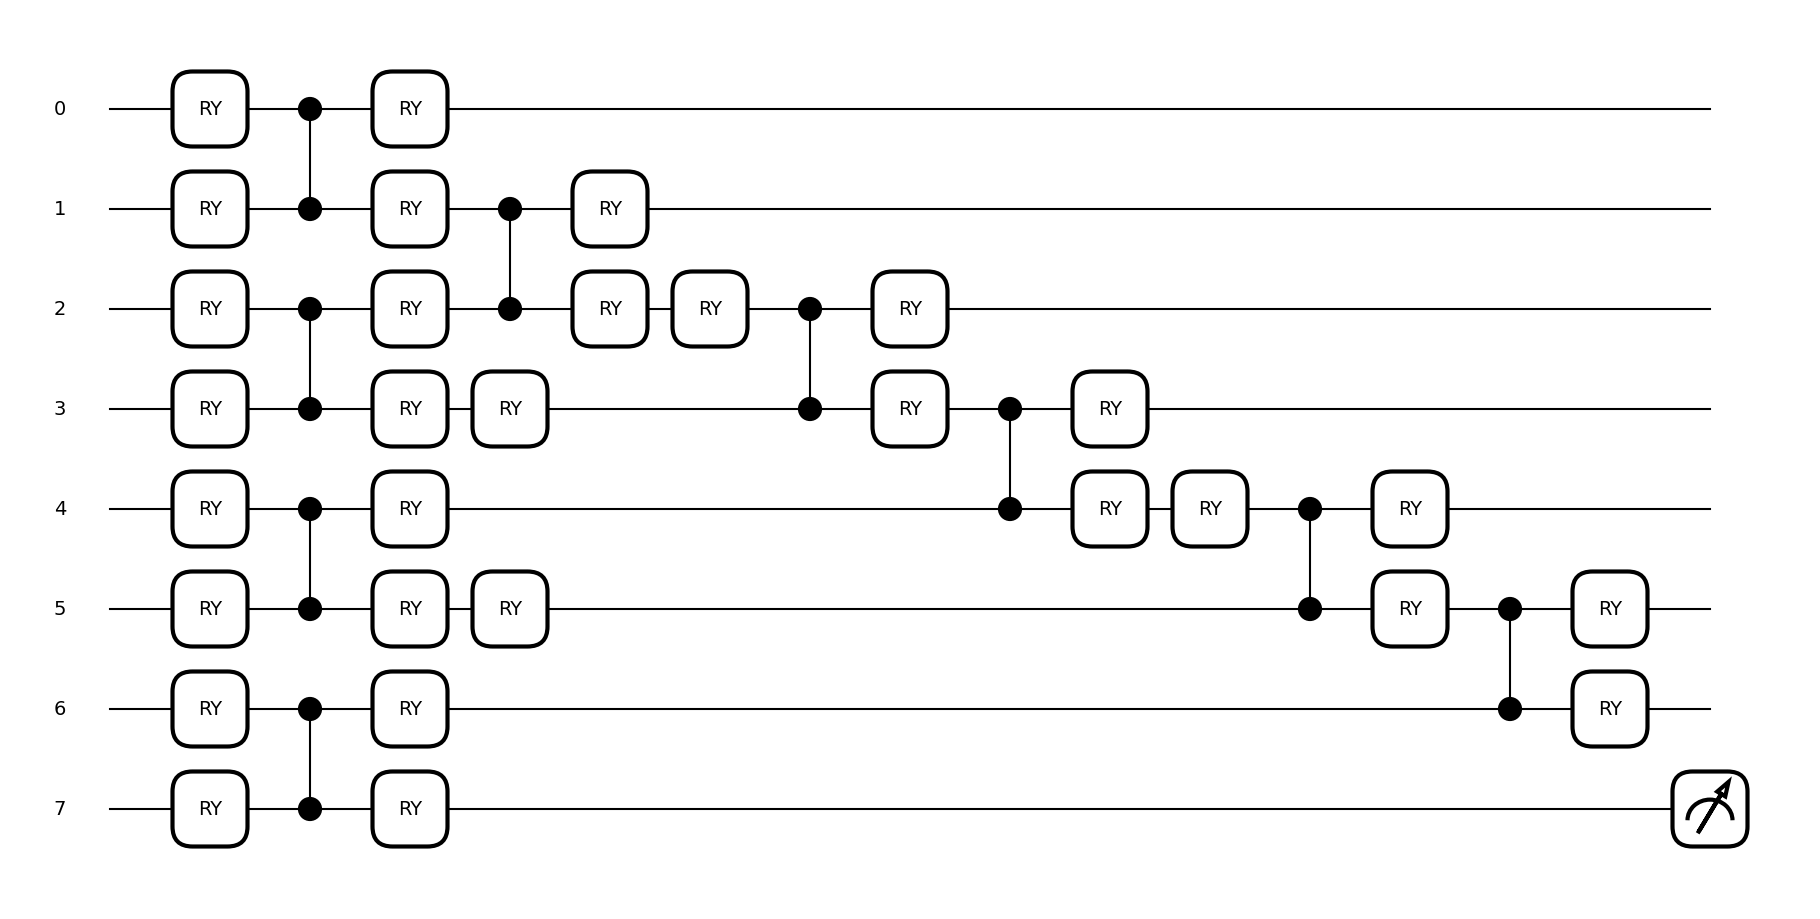

In [9]:
def wide_block(weights, wires):
    qml.SimplifiedTwoDesign(initial_layer_weights=weights[0], weights=weights[1], wires=wires)
dev = qml.device("default.qubit", wires=8)


@qml.qnode(dev)
def circuit(template_weights):
    qml.MPS(
        wires=range(8),
        n_block_wires=4, #cada bloque 4qubits a la vez
        block=wide_block,
        n_params_block=2,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=7))


shapes = qml.SimplifiedTwoDesign.shape(n_layers=1, n_wires=4)
weights = [onp.random.random(size=shape) for shape in shapes]
template_weights = onp.array([weights] * 3, dtype="object")
fig, ax = qml.draw_mpl(circuit, level="device")(template_weights)


MPS PARA MAXCUT

In [10]:
import pennylane as qml
from pennylane import numpy as np

graph = [(0,1), (0,3), (1,2), (2,3)]

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def block(weights, wires):
    qml.RY(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=wires)


# Circuito MPS para MaxCut
@qml.qnode(dev)
def circuit(params):

    # estado inicial uniforme
    for w in range(n_qubits):
        qml.Hadamard(wires=w)

    #MPS structure
    qml.MPS(
        wires=range(n_qubits),
        n_block_wires=2,
        block=block,
        n_params_block=2,
        template_weights=params
    )

    # Hamiltoniano de MaxCut
    return qml.expval(
        sum(qml.PauliZ(i) @ qml.PauliZ(j) for i, j in graph)
    )

In [11]:
def cost(params):
    return -0.5 * (len(graph) - circuit(params))

In [16]:
params = np.random.random(size=(3, 2), requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.1)

for i in range(100):
    params = opt.step(cost, params)
    if i % 20 == 0:
        print("step", i, "cost", cost(params))

step 0 cost -2.7758288847452057
step 20 cost -3.9388420919212077
step 40 cost -3.9978958733253345
step 60 cost -3.9999005384100066
step 80 cost -3.9999949403413546


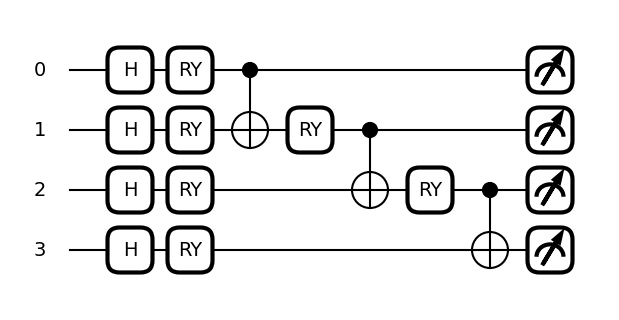

In [14]:
np.random.seed(1)
weights = np.random.random(size=[3, 2])
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(circuit, level="device")(weights)
fig.set_size_inches((6, 3))

Classifying the bars and stripes data set:  learning problem con TTN

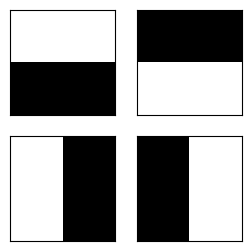

In [17]:
import matplotlib.pyplot as plt

BAS = [[1, 1, 0, 0], [0, 0, 1, 1], [1, 0, 1, 0], [0, 1, 0, 1]]
j = 1
plt.figure(figsize=[3, 3])
for i in BAS:
    plt.subplot(2, 2, j)
    j += 1
    plt.imshow(np.reshape(i, [2, 2]), cmap="gray")
    plt.xticks([])
    plt.yticks([])

define the parameterized quantum circuit that will be trained to label the images

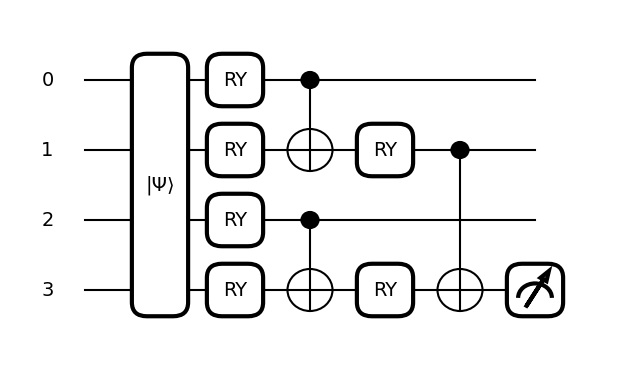

In [18]:
def block(weights, wires):
    qml.RY(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=wires)

dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def circuit(image, template_weights):
    qml.BasisState(image, wires=range(4)) #encode the input images
    qml.TTN(
        wires=range(4),
        n_block_wires=2,
        block=block,
        n_params_block=2,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=3)) #measurement as the output


weights = np.random.random(size=[3, 2])
fig, ax = qml.draw_mpl(circuit, level="device")(BAS[0], weights)
fig.set_size_inches((6, 3.5))

Minimizar cost implica: hacer los valores de stripes más negativos ylos valores de bars más positivos

separar clases en el espacio cuántico



Cada paso del optimizer:ejecuta el circuito con todos los datos, calcula el coste global, calcula gradientes (parameter-shift), ajusta los weight

Step 0, cost: -0.02926337991288247
Step 20, cost: -3.9996288201097125
Step 40, cost: -3.9999999999995035
Step 60, cost: -3.9999999999999996
Step 80, cost: -4.0


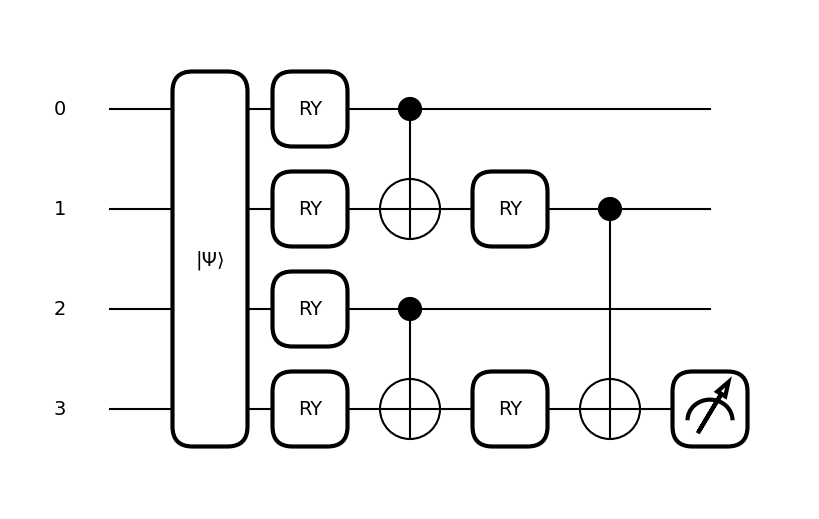

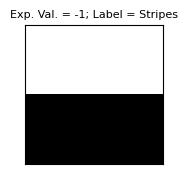

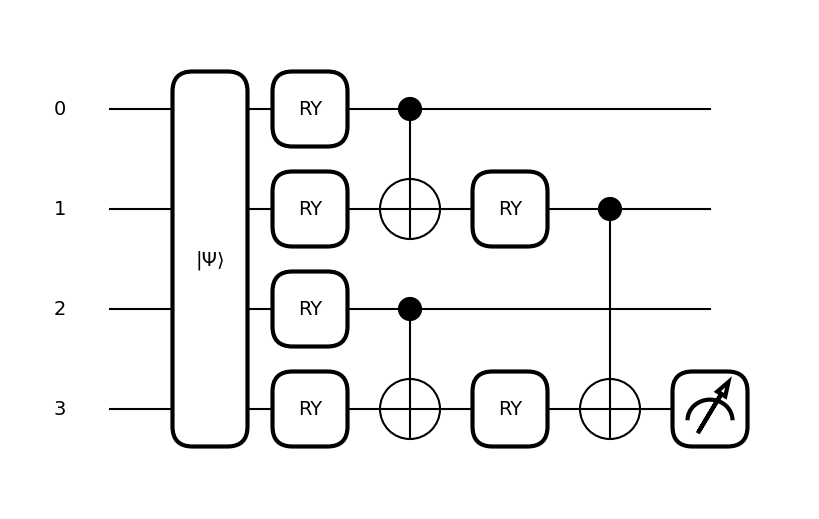

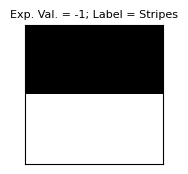

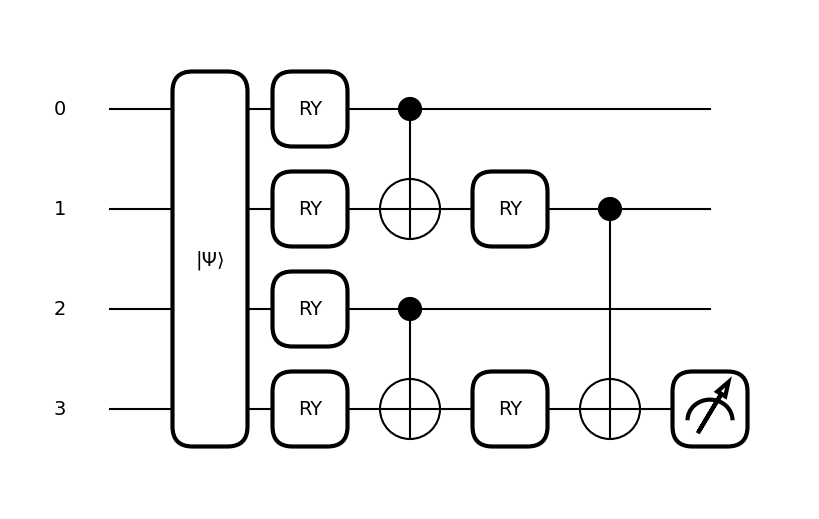

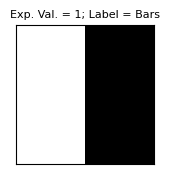

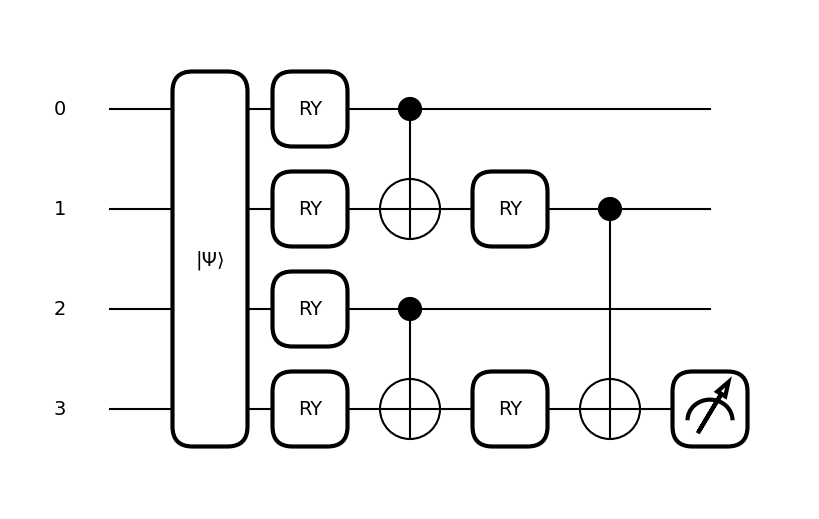

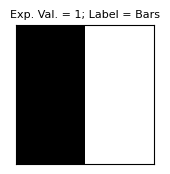

In [20]:
def costfunc(params):
    cost = 0
    for i in range(len(BAS)):
        if i < len(BAS) / 2:   #onvierte una salida continua en una etiqueta discreta
            cost += circuit(BAS[i], params)
        else:
            cost -= circuit(BAS[i], params)
    return cost
params = np.random.random(size=[3, 2], requires_grad=True)
optimizer = qml.GradientDescentOptimizer(stepsize=0.1)

for k in range(100):
    if k % 20 == 0:
        print(f"Step {k}, cost: {costfunc(params)}")
    params = optimizer.step(costfunc, params)

for image in BAS:
    fig, ax = qml.draw_mpl(circuit, level="device")(image, params)
    plt.figure(figsize=[1.8, 1.8])
    plt.imshow(np.reshape(image, [2, 2]), cmap="gray")
    plt.title(
        f"Exp. Val. = {circuit(image,params):.0f};"
        + f" Label = {'Bars' if circuit(image,params)>0 else 'Stripes'}",
        fontsize=8,
    )
    plt.xticks([])
    plt.yticks([])